# Exploratory Data Analysis.

#### Purpose:
The purpose of this script is to gain an initial understanding of the dataset by identifying patterns, detecting anomalies, and evaluating relationships between key variables. This helps ensure data quality, guides preprocessing decisions, and provides insights that support later modeling steps.

In [105]:
import pandas as pd
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Import data
file_path = './ocean_out/telemetry_with_era5_ocean_density.parquet'
#file_path = './Final_datasets/telemetry_final_TRAVIATA.parquet'
df = pd.read_parquet(file_path)
cols_to_drop = ["draft_fwd", "draft_aft", "VesselName", "goodwx"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [106]:
df.head()


,timestamp,Draught_A_m,Draught_F_m,Latitude_deg,Longitude_deg,SpeedOverGround_kn,HeadingTrue_deg,SpeedThroughWater_kn,WindAngleRelative_deg,WindSpeedRelative_m_s,...,mwd,mwp,swh,u10,v10,uo,vo,thetao,so,rho_surface
0,2023-01-01 03:00:00+00:00,10.550000,11.370000,7.992398,75.173276,16.688800,-63.850000,17.683333,17.500000,6.316667,...,149.732117,8.493224,1.103765,-0.032808,-3.484026,0.369531,-0.297169,28.068027,32.614758,1020.501917
1,2023-01-01 03:01:00+00:00,10.565000,11.363333,7.994390,75.168818,16.731833,-64.050000,17.738334,21.800000,5.760000,...,149.770020,8.495083,1.103362,-0.037797,-3.480294,0.369839,-0.295297,28.067722,32.615356,1020.502455
2,2023-01-01 03:02:00+00:00,10.565000,11.340000,7.996381,75.164340,16.757833,-63.833333,17.750000,23.000000,6.683333,...,149.807648,8.496928,1.102962,-0.042771,-3.476569,0.369322,-0.293678,28.067677,32.616329,1020.503184
3,2023-01-01 03:03:00+00:00,10.556667,11.326667,7.998265,75.160101,16.752500,-64.016667,17.763333,21.666667,7.000000,...,149.842987,8.498659,1.102586,-0.047459,-3.473059,0.368082,-0.292337,28.067795,32.617477,1020.503989
4,2023-01-01 03:04:00+00:00,10.560000,11.315000,8.000107,75.155931,16.731000,-63.950000,17.738334,20.200000,7.580000,...,149.877289,8.500340,1.102220,-0.052030,-3.469631,0.366828,-0.291009,28.067862,32.618534,1020.504743


In [107]:
df.columns


Index(['timestamp', 'Draught_A_m', 'Draught_F_m', 'Latitude_deg',
       'Longitude_deg', 'SpeedOverGround_kn', 'HeadingTrue_deg',
       'SpeedThroughWater_kn', 'WindAngleRelative_deg',
       'WindSpeedRelative_m_s', 'ShaftPower_kW', 'ShaftRev_rpm',
       'FuelOilFlowmeter_kg_h', 'op_mode_group', 'row_id', 'mwd', 'mwp', 'swh',
       'u10', 'v10', 'uo', 'vo', 'thetao', 'so', 'rho_surface'],
      dtype='object')

In [108]:
df.index


RangeIndex(start=0, stop=780345, step=1)

In [109]:
df.shape

(780345, 25)

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Parse timestamp og sorter
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.sort_values("timestamp")

# 2) Sjekk missing timestamps og duplikater
n_null_ts = df["timestamp"].isna().sum()
n_dup_ts = df["timestamp"].duplicated().sum()

print("Rows:", len(df))
print("Null timestamps:", n_null_ts)
print("Duplicate timestamps:", n_dup_ts)

# 3) Sett timestamp som index (anbefalt for resample)
df = df.set_index("timestamp")

print("Start:", df.index.min())
print("End  :", df.index.max())
print("Span :", df.index.max() - df.index.min())


Rows: 780345
Null timestamps: 0
Duplicate timestamps: 0
Start: 2023-01-01 03:00:00+00:00
End  : 2025-07-24 23:59:00+00:00
Span : 935 days 20:59:00


Daily coverage:
  Total days: 936
  Mean rows/day: 833.7019230769231
  Median rows/day: 1300.5
  Min rows/day: 0
  Days below 80% of 1-min coverage: 458

Sampling interval (seconds):
  median_dt_s: 60.000
  mean_dt_s: 103.620
  p95_dt_s: 60.000
  p99_dt_s: 60.000
  max_dt_s: 3,243,060.000


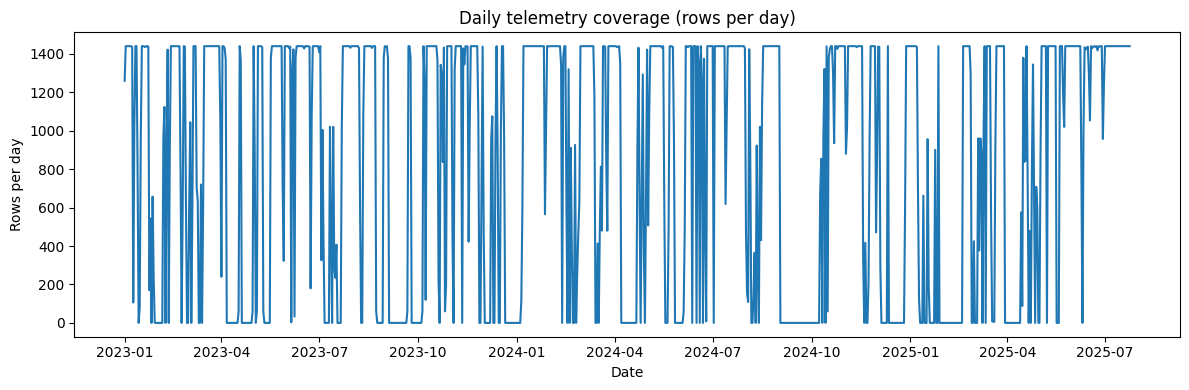

In [111]:
# 5.1 Coverage and sampling: daily coverage + gaps

# Antall rader per dag
daily_counts = df.resample("D").size()

# Gap-analyse (basert på tidsindeksen)
dt = df.index.to_series().diff().dropna()
gap_summary = {
    "median_dt_s": float(dt.median().total_seconds()),
    "mean_dt_s": float(dt.mean().total_seconds()),
    "p95_dt_s": float(dt.quantile(0.95).total_seconds()),
    "p99_dt_s": float(dt.quantile(0.99).total_seconds()),
    "max_dt_s": float(dt.max().total_seconds()),
}

# Antall dager med "lav dekning" (du kan justere terskel)
low_day_threshold = 60 * 24 * 0.8  # forventet 1-min data ~1440/dag. 80% dekning ~1152
n_low_days = int((daily_counts < low_day_threshold).sum())
n_total_days = int(daily_counts.shape[0])

print("Daily coverage:")
print("  Total days:", n_total_days)
print("  Mean rows/day:", float(daily_counts.mean()))
print("  Median rows/day:", float(daily_counts.median()))
print("  Min rows/day:", int(daily_counts.min()))
print("  Days below 80% of 1-min coverage:", n_low_days)

print("\nSampling interval (seconds):")
for k, v in gap_summary.items():
    print(f"  {k}: {v:,.3f}")

# Plot: daily row counts
plt.figure(figsize=(12,4))
plt.plot(daily_counts.index, daily_counts.values)
plt.title("Daily telemetry coverage (rows per day)")
plt.xlabel("Date")
plt.ylabel("Rows per day")
plt.tight_layout()
plt.show()


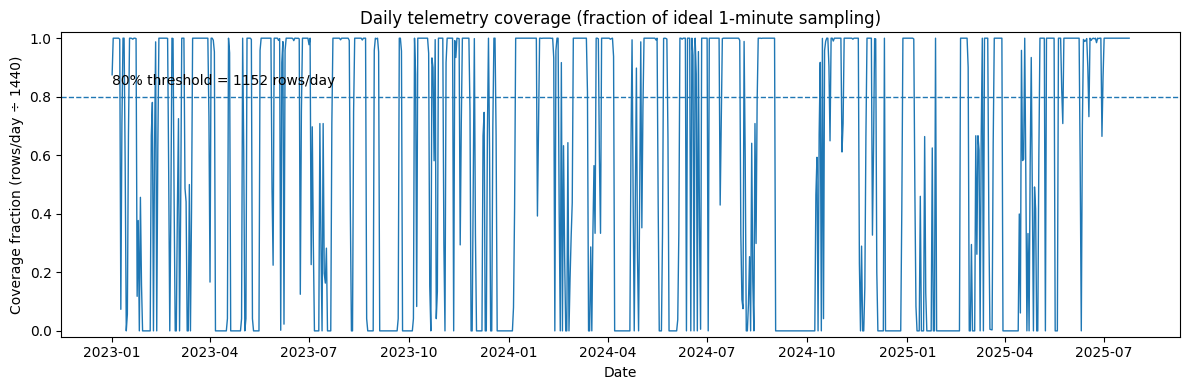

In [112]:
# Daily coverage as fraction of ideal 1-min sampling (1440/day) + 80% threshold line

import numpy as np
import matplotlib.pyplot as plt

# Rows per day (already in your code)
daily_counts = df.resample("D").size()

# Normalize by ideal 1-min sampling
ideal_per_day = 60 * 24  # 1440
daily_fraction = (daily_counts / ideal_per_day).clip(lower=0, upper=1)

# Threshold (80% completeness)
thr_frac = 0.8
thr_rows = int(ideal_per_day * thr_frac)

plt.figure(figsize=(12, 4))
plt.plot(daily_fraction.index, daily_fraction.values, linewidth=1.0)
plt.axhline(thr_frac, linestyle="--", linewidth=1.0)

plt.title("Daily telemetry coverage (fraction of ideal 1-minute sampling)")
plt.xlabel("Date")
plt.ylabel("Coverage fraction (rows/day ÷ 1440)")
plt.ylim(-0.02, 1.02)

# Optional: annotate threshold in text (keeps figure self-explanatory)
plt.text(daily_fraction.index.min(), thr_frac + 0.03,
         f"80% threshold = {thr_rows} rows/day", va="bottom")

plt.tight_layout()

# Optional: save for LaTeX (recommended)
# plt.savefig("figures/daily_coverage_fraction.pdf", bbox_inches="tight")

plt.show()


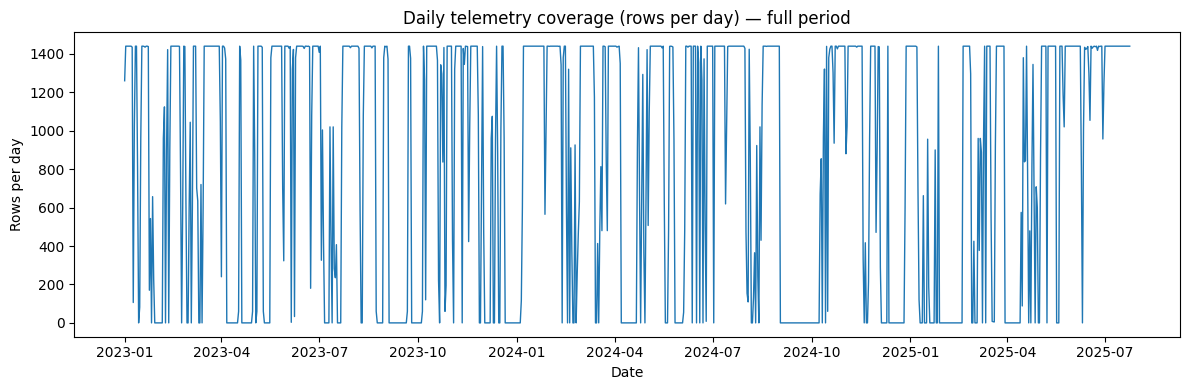

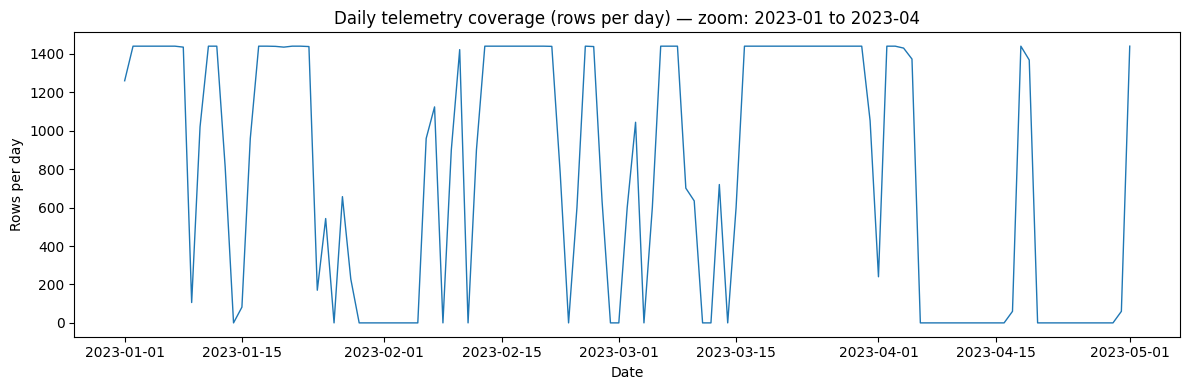

In [113]:
# Daily coverage (rows/day) with full-period plot + zoomed-in plot (2023-01 to 2023-04)

import matplotlib.pyplot as plt

# Rows per day
daily_counts = df.resample("D").size()

# Full period
plt.figure(figsize=(12, 4))
plt.plot(daily_counts.index, daily_counts.values, linewidth=1.0)
plt.title("Daily telemetry coverage (rows per day) — full period")
plt.xlabel("Date")
plt.ylabel("Rows per day")
plt.tight_layout()
# Optional save:
# plt.savefig("figures/daily_coverage_full.pdf", bbox_inches="tight")
plt.show()

# Zoomed period (inclusive start, exclusive end)
start = "2023-01-01"
end   = "2023-05-01"  # shows Jan–Apr

daily_zoom = daily_counts.loc[start:end]

plt.figure(figsize=(12, 4))
plt.plot(daily_zoom.index, daily_zoom.values, linewidth=1.0)
plt.title("Daily telemetry coverage (rows per day) — zoom: 2023-01 to 2023-04")
plt.xlabel("Date")
plt.ylabel("Rows per day")
plt.tight_layout()
# Optional save:
# plt.savefig("figures/daily_coverage_zoom_2023Q1.pdf", bbox_inches="tight")
plt.show()


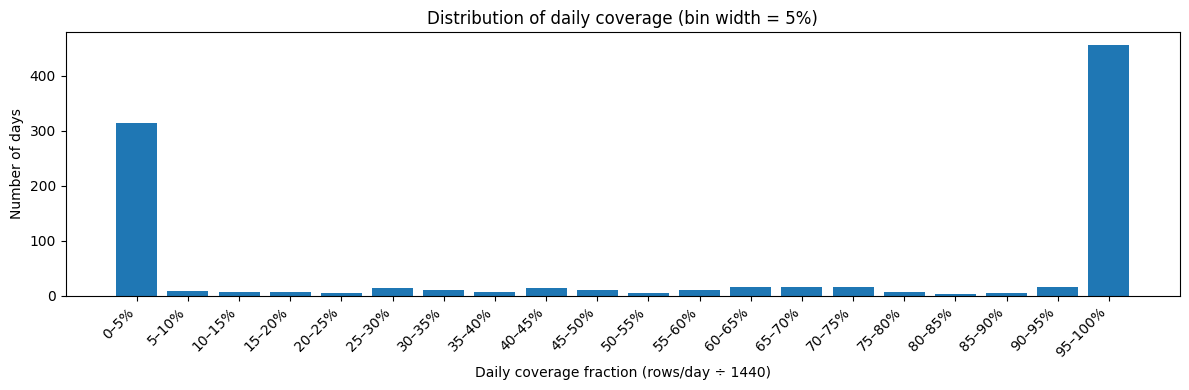

Days with >= 100% of ideal coverage (>= 1440 rows/day): 387


In [114]:
 # Distribution of daily coverage: how many days fall into 0–100% completeness bins

import numpy as np
import matplotlib.pyplot as plt

# Rows per day
daily_counts = df.resample("D").size()

ideal_per_day = 60 * 24  # 1440
daily_frac = (daily_counts / ideal_per_day).clip(lower=0, upper=1)

# Bin into coverage percentages (e.g., 0–5–10–...–100%)
bin_width_pct = 5  # change to 1 or 10 if you prefer
edges = np.arange(0, 100 + bin_width_pct, bin_width_pct) / 100.0  # 0..1
labels = [f"{int(edges[i]*100)}–{int(edges[i+1]*100)}%" for i in range(len(edges)-1)]

counts, _ = np.histogram(daily_frac.values, bins=edges)

plt.figure(figsize=(12, 4))
x = np.arange(len(counts))
plt.bar(x, counts)
plt.xticks(x, labels, rotation=45, ha="right")
plt.title(f"Distribution of daily coverage (bin width = {bin_width_pct}%)")
plt.xlabel("Daily coverage fraction (rows/day ÷ 1440)")
plt.ylabel("Number of days")
plt.tight_layout()

# Optional save:
# plt.savefig("figures/daily_coverage_distribution.png", dpi=200, bbox_inches="tight")

plt.show()

# Optional: print how many days are essentially "full coverage"
full_days = int((daily_counts >= ideal_per_day).sum())
print(f"Days with >= 100% of ideal coverage (>= {ideal_per_day} rows/day): {full_days}")


In [115]:
# Mode of rows per day (and how many days share it)

daily_counts = df.resample("D").size()

mode_rows = int(daily_counts.mode().iloc[0])          # most frequent value
n_mode = int((daily_counts == mode_rows).sum())       # how many days have that value

print(f"Mode (rows/day): {mode_rows}")
print(f"Number of days at mode: {n_mode}")

# If you want to see ties (multiple modes), uncomment:
# modes = daily_counts.value_counts()
# max_freq = modes.iloc[0]
# all_modes = modes[modes == max_freq].index.astype(int).tolist()
# print(f"All modes: {all_modes} (each occurs {int(max_freq)} days)")


Mode (rows/day): 1440
Number of days at mode: 387


In [116]:
# --- Gap analysis: find and summarize long gaps ---
ts = df.index.to_series().sort_values()
dt = ts.diff()

# Define what counts as a "gap" (adjust as you like)
gap_threshold = pd.Timedelta(hours=6)

gaps = dt[dt > gap_threshold].sort_values(ascending=False)

print(f"Number of gaps > {gap_threshold}: {len(gaps)}")
if len(gaps) > 0:
    print("Top 10 gaps:")
    display(pd.DataFrame({
        "gap_start": gaps.index - gaps.values,
        "gap_end": gaps.index,
        "gap_duration": gaps.values
    }).head(10))

    # Optional: count gaps by size bucket
    bins = [
        pd.Timedelta(hours=6),
        pd.Timedelta(days=1),
        pd.Timedelta(days=7),
        pd.Timedelta(days=30),
        pd.Timedelta(days=365),
    ]
    labels = ["6h–1d", "1–7d", "7–30d", "30d–1y"]
    gap_bucket = pd.cut(gaps.values.astype("timedelta64[s]").astype(float),
                        bins=[b.total_seconds() for b in bins],
                        labels=labels,
                        include_lowest=True)
    print("\nGap duration buckets:")
    print(gap_bucket.value_counts(dropna=False))


Number of gaps > 0 days 06:00:00: 129
Top 10 gaps:


,gap_start,gap_end,gap_duration
0,2024-09-01 23:59:00+00:00,2024-10-09 12:50:00+00:00,37 days 12:51:00
1,2025-01-27 23:59:00+00:00,2025-02-19 00:00:00+00:00,22 days 00:01:00
2,2023-09-03 22:59:00+00:00,2023-09-21 23:00:00+00:00,18 days 00:01:00
3,2023-12-20 16:02:00+00:00,2024-01-05 11:00:00+00:00,15 days 18:58:00
4,2024-12-11 23:59:00+00:00,2024-12-27 14:00:00+00:00,15 days 14:01:00
5,2024-04-06 22:29:00+00:00,2024-04-22 08:50:00+00:00,15 days 10:21:00
6,2025-03-29 23:59:00+00:00,2025-04-14 00:00:00+00:00,15 days 00:01:00
7,2023-04-05 22:59:00+00:00,2023-04-17 23:00:00+00:00,12 days 00:01:00
8,2023-09-24 22:59:00+00:00,2023-10-05 23:00:00+00:00,11 days 00:01:00
9,2023-04-19 22:59:00+00:00,2023-04-30 23:00:00+00:00,11 days 00:01:00



Gap duration buckets:
6h–1d     34
1–7d      80
7–30d     14
30d–1y     1
Name: count, dtype: int64


In [138]:
# --- 5.2 Missingness: overall missing rate per variable ---
missing_frac = df.isna().mean().sort_values(ascending=False)

print("Top 15 variables by missing fraction:")
display(missing_frac.head(15).to_frame("missing_fraction"))

# Optional: split telemetry vs metocean (adjust lists to your conventions)
metocean_cols = ["mwd","mwp","swh","u10","v10","uo","vo","thetao","so","rho_surface"]
telemetry_cols = [c for c in df.columns if c not in metocean_cols]

print("\nMissingness summary:")
print("Telemetry mean missing fraction:", df[telemetry_cols].isna().mean().mean())
print("Metocean  mean missing fraction:", df[metocean_cols].isna().mean().mean())


Top 15 variables by missing fraction:


,missing_fraction
mwd,0.032164
swh,0.032164
mwp,0.032164
Draught_A_m,0.022730
so,0.019458
thetao,0.019458
vo,0.019458
uo,0.019458
rho_surface,0.019458
Draught_F_m,0.015465



Missingness summary:
Telemetry mean missing fraction: 0.005695008526448467
Metocean  mean missing fraction: 0.019899531617425626


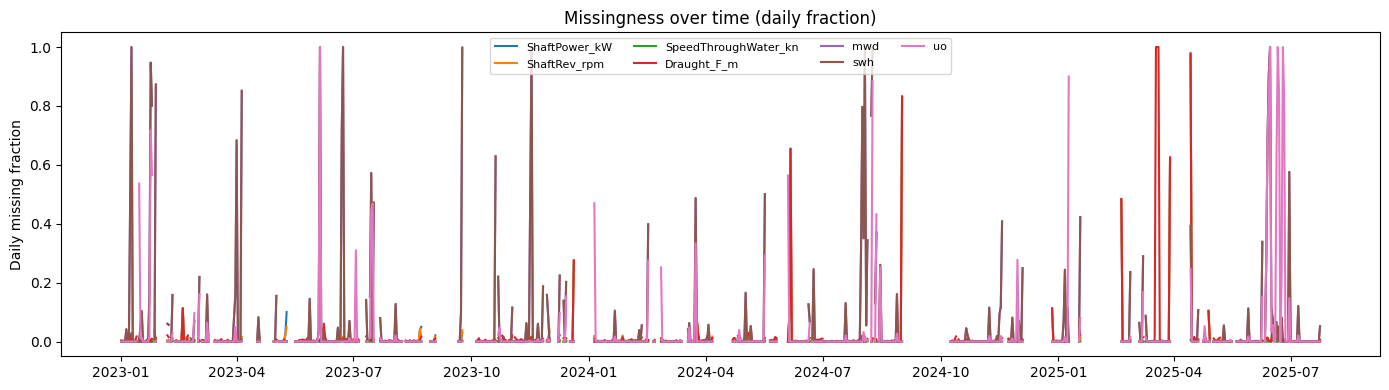

In [118]:
# --- Missingness over time: daily missing fraction for selected variables ---
vars_to_track = [
    "ShaftPower_kW", "ShaftRev_rpm", "SpeedThroughWater_kn",
    "Draught_F_m", "mwd", "swh", "uo"
]

# sikkerhet: bare ta de som finnes
vars_to_track = [v for v in vars_to_track if v in df.columns]

daily_missing = df[vars_to_track].isna().resample("D").mean()

plt.figure(figsize=(14,4))
for v in vars_to_track:
    plt.plot(daily_missing.index, daily_missing[v], label=v)
plt.ylabel("Daily missing fraction")
plt.title("Missingness over time (daily fraction)")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


In [119]:
# --- Quantify burstiness: days with high missing per variable ---
vars_to_track = ["ShaftPower_kW","ShaftRev_rpm","SpeedThroughWater_kn","Draught_F_m","mwd","swh","uo"]
vars_to_track = [v for v in vars_to_track if v in df.columns]

daily_missing = df[vars_to_track].isna().resample("D").mean()

summary = pd.DataFrame({
    "days_total": daily_missing.shape[0],
    "days_any_missing": (daily_missing > 0).sum(),
    "days_gt_10pct": (daily_missing > 0.10).sum(),
    "days_gt_50pct": (daily_missing > 0.50).sum(),
    "days_full_missing": (daily_missing >= 0.999).sum(),
})

# sorter etter alvorlighet
summary = summary.sort_values("days_full_missing", ascending=False)
summary


,days_total,days_any_missing,days_gt_10pct,days_gt_50pct,days_full_missing
mwd,936,150,74,22,7
swh,936,150,74,22,7
Draught_F_m,936,518,16,10,4
uo,936,107,36,15,4
ShaftPower_kW,936,169,12,7,1
ShaftRev_rpm,936,281,12,7,1
SpeedThroughWater_kn,936,81,1,0,0


Operation mode distribution (top):


,count,fraction
op_mode_group,,
SEA PASSAGE,780345,1.0


/var/folders/y4/fj894jm941g0dwsysy6kkmm80000gn/T/ipykernel_24962/3325312225.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=3)


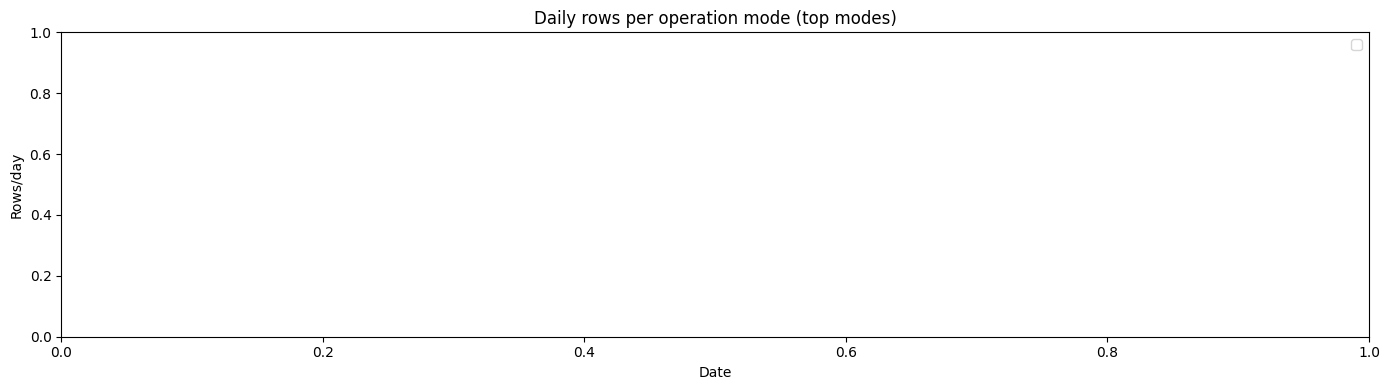

No obvious 'sea passage' label found in op_mode_group (check naming).


In [120]:
import matplotlib.pyplot as plt

# 1) Overordnet fordeling av operation modes
mode_counts = df["op_mode_group"].value_counts(dropna=False)
mode_frac = mode_counts / mode_counts.sum()

print("Operation mode distribution (top):")
display(pd.DataFrame({"count": mode_counts, "fraction": mode_frac}).head(15))

# 2) Daily rows per mode (tidsprofil)
daily_by_mode = (
    df["op_mode_group"]
    .fillna("NaN")
    .groupby([pd.Grouper(freq="D"), lambda x: x])
    .size()
    .unstack(fill_value=0)
)

# Velg topp modes for plott (unngå altfor mange linjer)
top_modes = mode_counts.index[:6].astype(str)
daily_top = daily_by_mode.loc[:, [m for m in daily_by_mode.columns if str(m) in set(top_modes)]]

plt.figure(figsize=(14,4))
plt.title("Daily rows per operation mode (top modes)")
for col in daily_top.columns:
    plt.plot(daily_top.index, daily_top[col], label=str(col))
plt.ylabel("Rows/day")
plt.xlabel("Date")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

# 3) Andel dager uten sea passage (om label finnes)
sea_label_candidates = [c for c in daily_by_mode.columns if str(c).lower() in ["sea", "sea_passage", "seapassage", "sea passage"]]
if sea_label_candidates:
    sea_col = sea_label_candidates[0]
    days_no_sea = (daily_by_mode[sea_col] == 0).sum()
    print(f"Days with zero rows in '{sea_col}': {days_no_sea} / {len(daily_by_mode)}")
else:
    print("No obvious 'sea passage' label found in op_mode_group (check naming).")


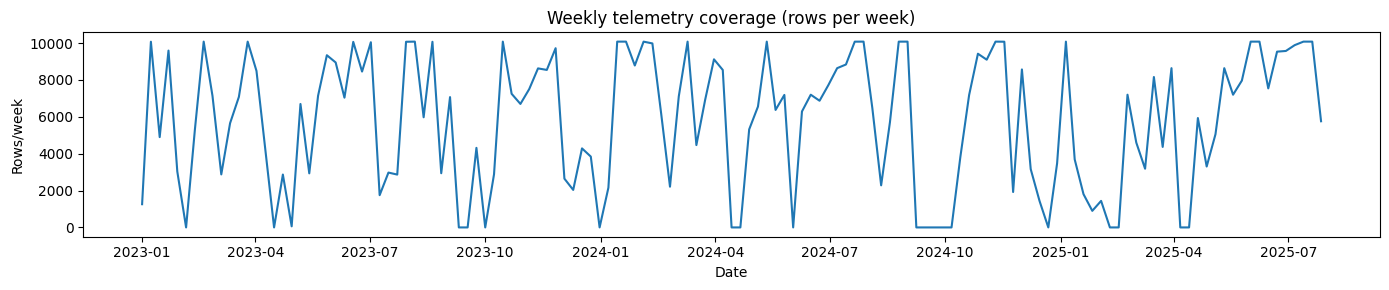

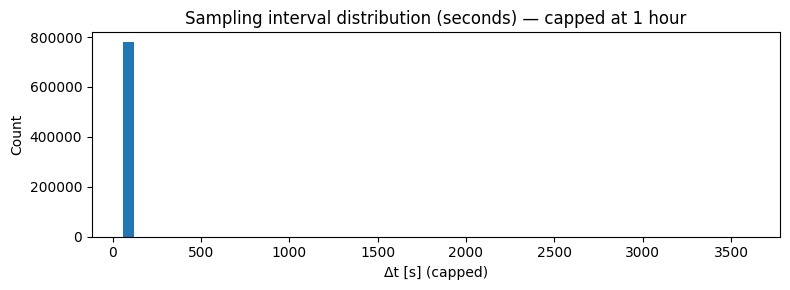

Share of exact 60s sampling: 0.9993541309986365


In [121]:
# Weekly coverage (rows/week)
weekly_counts = df.resample("W").size()
plt.figure(figsize=(14,3))
plt.title("Weekly telemetry coverage (rows per week)")
plt.plot(weekly_counts.index, weekly_counts.values)
plt.ylabel("Rows/week"); plt.xlabel("Date")
plt.tight_layout(); plt.show()

# Sampling interval distribution (cap extreme gaps for readability)
ts = df.index.sort_values()
dt_s = ts.to_series().diff().dt.total_seconds().dropna()

plt.figure(figsize=(8,3))
plt.title("Sampling interval distribution (seconds) — capped at 1 hour")
plt.hist(dt_s.clip(upper=3600), bins=60)
plt.xlabel("Δt [s] (capped)"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

print("Share of exact 60s sampling:", (dt_s == 60).mean())


,missing_frac,q00,q01,q05,q50,q95,q99,q100
swh,0.032164,0.033102,0.217622,0.409499,1.797317,3.483322,4.365251,5.617629
mwd,0.032164,0.078776,7.290679,30.578400,198.492706,335.234589,354.733704,359.977875
mwp,0.032164,1.645883,2.811351,3.681395,7.950088,11.443787,13.071131,14.780456
Draught_A_m,0.022730,6.096667,8.110000,8.415000,10.015000,10.545000,10.660000,11.260000
rho_surface,0.019458,997.620033,1018.309719,1019.964946,1024.370565,1026.693091,1027.792507,1030.980171
vo,0.019458,-1.561181,-0.613680,-0.314266,-0.007061,0.316283,0.598849,1.259612
uo,0.019458,-1.493571,-0.704216,-0.382421,-0.014994,0.331121,0.630831,1.784655
Draught_F_m,0.015465,6.443333,7.635000,8.315000,10.510000,11.250000,11.455000,12.460000
ShaftRev_rpm,0.013193,0.000000,0.000000,0.000000,78.066667,93.612500,95.157750,97.366667
ShaftPower_kW,0.012612,0.000000,0.000000,0.000000,6277.454545,10934.000000,11784.545455,13030.250000


Plausibility flags (count):
                    STW_negative: 0
                    SOG_negative: 0
                  Power_negative: 0
                    RPM_negative: 0
                Draft_F_negative: 0
                Draft_A_negative: 0
                    SWH_negative: 0
   Heading_outside_common_ranges: 438


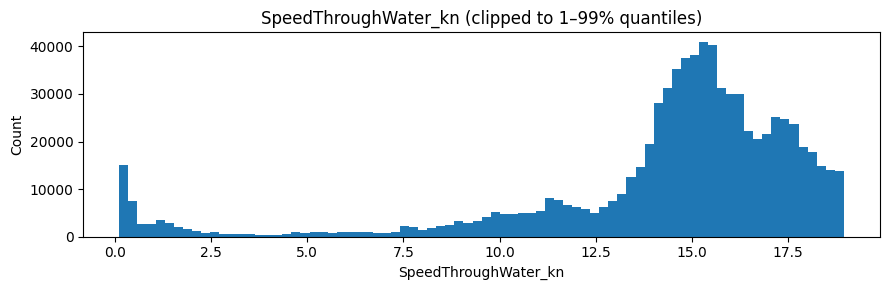

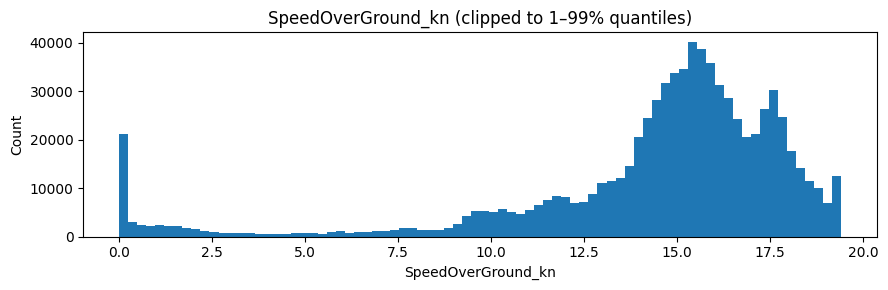

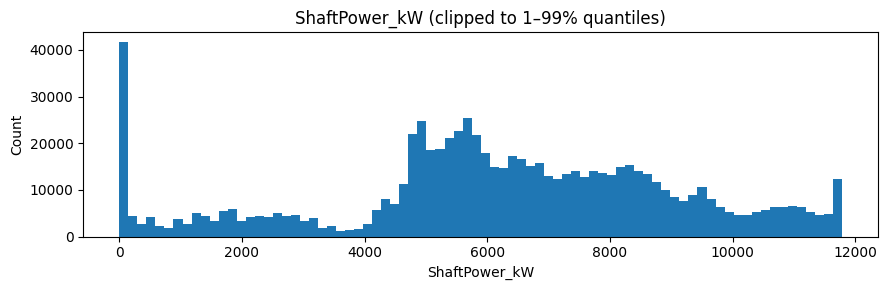

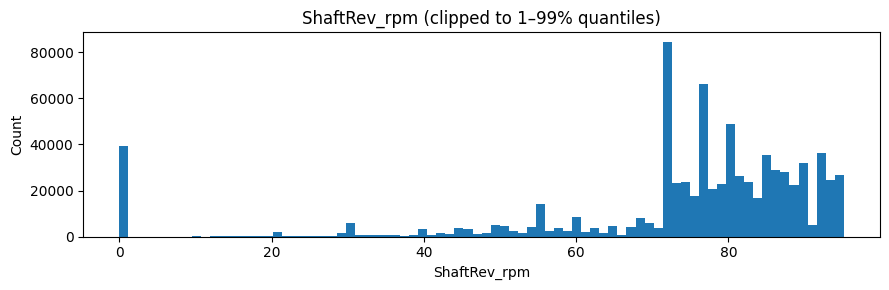

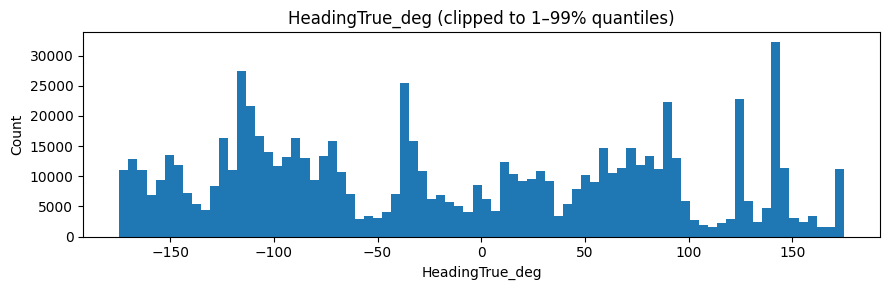

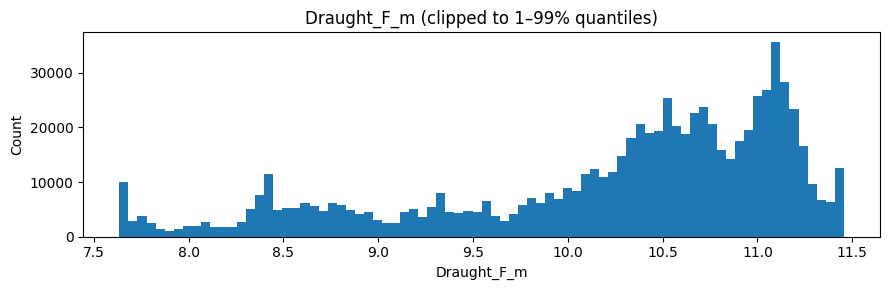

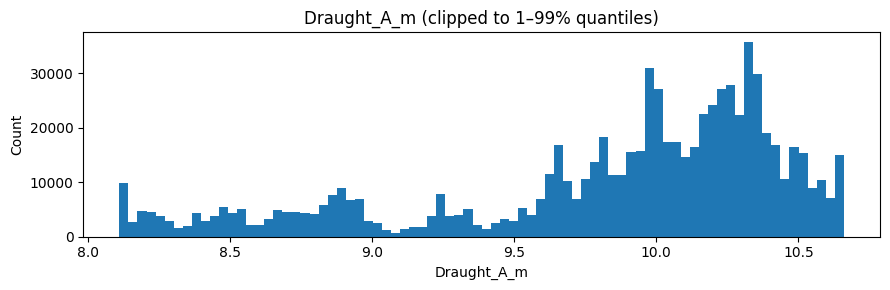

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 5.3 Value ranges and anomalies ---

vars_5_3 = [
    "SpeedThroughWater_kn", "SpeedOverGround_kn",
    "ShaftPower_kW", "ShaftRev_rpm",
    "Draught_F_m", "Draught_A_m",
    "HeadingTrue_deg",
    "WindSpeedRelative_m_s", "WindAngleRelative_deg",
    "swh", "mwd", "mwp", "u10", "v10", "uo", "vo", "rho_surface"
]
vars_5_3 = [v for v in vars_5_3 if v in df.columns]

# Kvantil-basert range-tabell
qs = [0.00, 0.01, 0.05, 0.50, 0.95, 0.99, 1.00]
range_audit = df[vars_5_3].quantile(qs).T
range_audit.columns = [f"q{int(q*100):02d}" for q in qs]
range_audit.insert(0, "missing_frac", df[vars_5_3].isna().mean().values)
display(range_audit.sort_values("missing_frac", ascending=False))

# Plausibilitetsflagg (fysiske umuligheter / typiske sensorfeil)
flags = {}

if "SpeedThroughWater_kn" in df.columns:
    flags["STW_negative"] = int((df["SpeedThroughWater_kn"] < 0).sum())
if "SpeedOverGround_kn" in df.columns:
    flags["SOG_negative"] = int((df["SpeedOverGround_kn"] < 0).sum())
if "ShaftPower_kW" in df.columns:
    flags["Power_negative"] = int((df["ShaftPower_kW"] < 0).sum())
if "ShaftRev_rpm" in df.columns:
    flags["RPM_negative"] = int((df["ShaftRev_rpm"] < 0).sum())
if "Draught_F_m" in df.columns:
    flags["Draft_F_negative"] = int((df["Draught_F_m"] < 0).sum())
if "Draught_A_m" in df.columns:
    flags["Draft_A_negative"] = int((df["Draught_A_m"] < 0).sum())
if "swh" in df.columns:
    flags["SWH_negative"] = int((df["swh"] < 0).sum())

# Heading sanity: tillat enten [-180, 180] eller [0, 360] (vi flagger bare hvis utenfor begge)
if "HeadingTrue_deg" in df.columns:
    h = df["HeadingTrue_deg"]
    out_both = ~(((h >= -180) & (h <= 180)) | ((h >= 0) & (h <= 360)))
    flags["Heading_outside_common_ranges"] = int(out_both.sum())

print("Plausibility flags (count):")
for k, v in flags.items():
    print(f"  {k:>30}: {v}")

# Distribusjonsplott (klipp til 1–99% for lesbarhet)
def hist_clip(series, title, bins=80):
    s = series.dropna()
    if len(s) == 0:
        return
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    plt.figure(figsize=(9, 3))
    plt.title(f"{title} (clipped to 1–99% quantiles)")
    plt.hist(s.clip(lo, hi), bins=bins)
    plt.xlabel(title); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

for v in ["SpeedThroughWater_kn", "SpeedOverGround_kn", "ShaftPower_kW", "ShaftRev_rpm", "HeadingTrue_deg", "Draught_F_m", "Draught_A_m"]:
    if v in df.columns:
        hist_clip(df[v], v)


In [123]:
import numpy as np
import pandas as pd

key = ["SpeedThroughWater_kn", "SpeedOverGround_kn", "ShaftPower_kW", "ShaftRev_rpm"]

# Definer "praktisk null" (robust mot avrunding og små støyverdier)
thr = {
    "SpeedThroughWater_kn": 0.2,
    "SpeedOverGround_kn": 0.2,
    "ShaftPower_kW": 50.0,
    "ShaftRev_rpm": 1.0,
}

z = pd.DataFrame(index=df.index)
for c in key:
    z[c] = df[c].fillna(np.nan) <= thr[c]

summary = pd.DataFrame({
    "count_practical_zero": z.sum(),
    "fraction_practical_zero": z.mean()
}).sort_values("fraction_practical_zero", ascending=False)

print("Practical-zero thresholds:", thr)
display(summary)

# Kombinasjoner (mest interessante for “SEA_PASSAGE men ikke transit”)
combo = pd.DataFrame({
    "power0_rpm0": (z["ShaftPower_kW"] & z["ShaftRev_rpm"]),
    "power0_rpm_pos": (z["ShaftPower_kW"] & ~z["ShaftRev_rpm"]),
    "power_pos_rpm0": (~z["ShaftPower_kW"] & z["ShaftRev_rpm"]),
    "stw0_power0_rpm0": (z["SpeedThroughWater_kn"] & z["ShaftPower_kW"] & z["ShaftRev_rpm"]),
    "stw_pos_power0_rpm0": (~z["SpeedThroughWater_kn"] & z["ShaftPower_kW"] & z["ShaftRev_rpm"]),
})

combo_stats = pd.DataFrame({
    "count": combo.sum(),
    "fraction": combo.mean()
}).sort_values("fraction", ascending=False)

display(combo_stats)

# Hvor mange rader har minst én "praktisk null" på de kritiske fremdriftsvariablene (power/rpm/stw)
crit_any = (z["ShaftPower_kW"] | z["ShaftRev_rpm"] | z["SpeedThroughWater_kn"])
print("Share with any practical-zero in (STW, Power, RPM):", crit_any.mean())


Practical-zero thresholds: {'SpeedThroughWater_kn': 0.2, 'SpeedOverGround_kn': 0.2, 'ShaftPower_kW': 50.0, 'ShaftRev_rpm': 1.0}


,count_practical_zero,fraction_practical_zero
ShaftPower_kW,39633,0.050789
ShaftRev_rpm,39174,0.050201
SpeedOverGround_kn,20440,0.026194
SpeedThroughWater_kn,10272,0.013163


,count,fraction
power0_rpm0,38542,0.049391
stw_pos_power0_rpm0,28618,0.036674
stw0_power0_rpm0,9924,0.012717
power0_rpm_pos,1091,0.001398
power_pos_rpm0,632,0.000810


Share with any practical-zero in (STW, Power, RPM): 0.05169380210035305


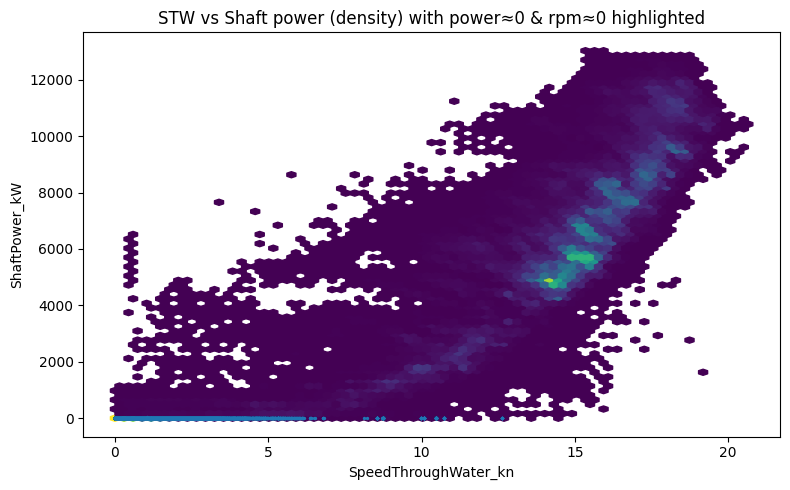

Share of power≈0 & rpm≈0 with STW > 2 kn: 0.004942685607007157


In [124]:
import numpy as np
import matplotlib.pyplot as plt

# Masker
power0 = df["ShaftPower_kW"].fillna(np.nan) <= 50.0
rpm0   = df["ShaftRev_rpm"].fillna(np.nan)   <= 1.0
mask_power0_rpm0 = power0 & rpm0

# Plot: STW vs Power (hexbin for tetthet) + overlay av power0_rpm0
x = df["SpeedThroughWater_kn"]
y = df["ShaftPower_kW"]

plt.figure(figsize=(8,5))
plt.title("STW vs Shaft power (density) with power≈0 & rpm≈0 highlighted")
plt.hexbin(x, y, gridsize=70, mincnt=1)
plt.xlabel("SpeedThroughWater_kn")
plt.ylabel("ShaftPower_kW")

# Overlay: de problematiske punktene
plt.scatter(x[mask_power0_rpm0], y[mask_power0_rpm0], s=2)

plt.tight_layout()
plt.show()

# Kvantifiser hvor mange av disse som har STW "meningsfull"
stw_pos = df["SpeedThroughWater_kn"] > 2.0
print("Share of power≈0 & rpm≈0 with STW > 2 kn:", (mask_power0_rpm0 & stw_pos).mean())


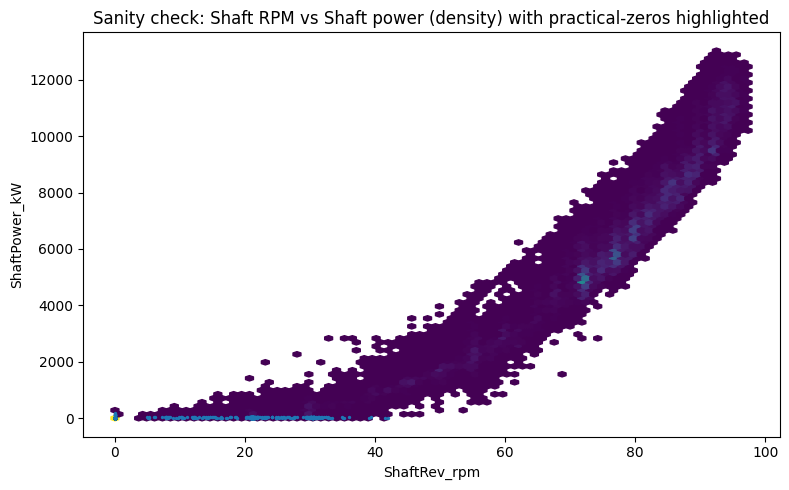

Share with practical-zero in power or rpm: 0.05159897224945377


In [125]:
import numpy as np
import matplotlib.pyplot as plt

power0 = df["ShaftPower_kW"] <= 50.0
rpm0   = df["ShaftRev_rpm"] <= 1.0
mask_zero = power0 | rpm0

x = df["ShaftRev_rpm"]
y = df["ShaftPower_kW"]

plt.figure(figsize=(8,5))
plt.title("Sanity check: Shaft RPM vs Shaft power (density) with practical-zeros highlighted")
plt.hexbin(x, y, gridsize=80, mincnt=1)
plt.xlabel("ShaftRev_rpm")
plt.ylabel("ShaftPower_kW")

plt.scatter(x[mask_zero], y[mask_zero], s=2)

plt.tight_layout()
plt.show()

print("Share with practical-zero in power or rpm:", mask_zero.mean())


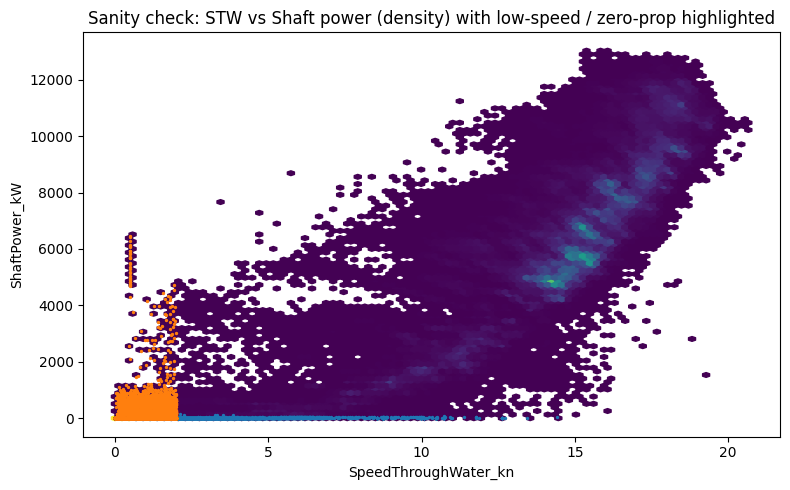

Share zero-prop (power<=50 or rpm<=1): 0.05159897224945377
Share low-speed (STW<=2 kn): 0.048411920368554934
Share either (union): 0.05412221517405763


In [126]:
import matplotlib.pyplot as plt

stw = df["SpeedThroughWater_kn"]
pwr = df["ShaftPower_kW"]
rpm = df["ShaftRev_rpm"]

mask_zero_prop = (pwr <= 50.0) | (rpm <= 1.0)
mask_low_speed = (stw <= 2.0)

plt.figure(figsize=(8,5))
plt.title("Sanity check: STW vs Shaft power (density) with low-speed / zero-prop highlighted")
plt.hexbin(stw, pwr, gridsize=90, mincnt=1)
plt.xlabel("SpeedThroughWater_kn")
plt.ylabel("ShaftPower_kW")

plt.scatter(stw[mask_zero_prop], pwr[mask_zero_prop], s=2)
plt.scatter(stw[mask_low_speed], pwr[mask_low_speed], s=2)

plt.tight_layout()
plt.show()

print("Share zero-prop (power<=50 or rpm<=1):", mask_zero_prop.mean())
print("Share low-speed (STW<=2 kn):", mask_low_speed.mean())
print("Share either (union):", (mask_zero_prop | mask_low_speed).mean())


Rows within thresholds: 40494 (5.1892%)


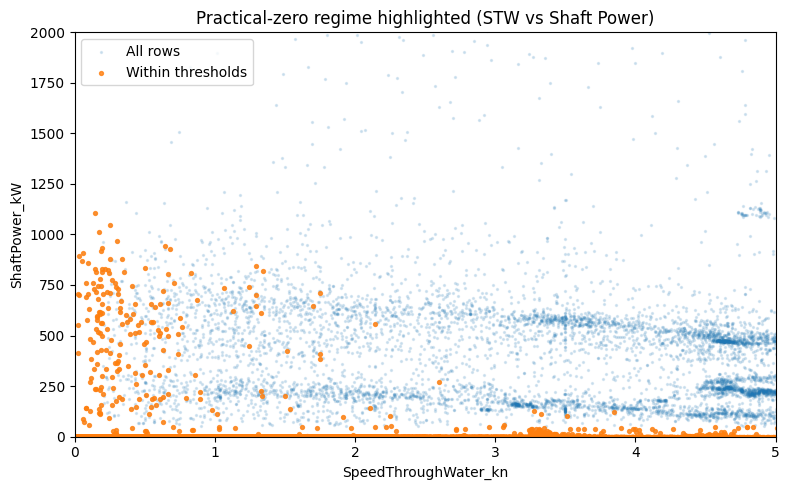

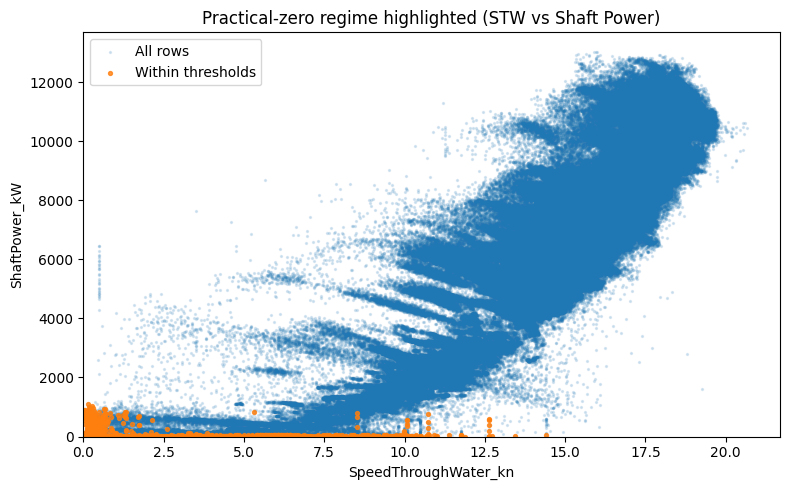

In [127]:
# Highlight rows that fall within the "practical-zero" thresholds:
# SpeedThroughWater_kn <= 0.2, SpeedOverGround_kn <= 0.2, ShaftPower_kW <= 50, ShaftRev_rpm <= 1

import matplotlib.pyplot as plt

mask_pzero = (
    (df["SpeedThroughWater_kn"] <= 0.2) |
    (df["SpeedOverGround_kn"] <= 0.2) |
    (df["ShaftPower_kW"] <= 50) |
    (df["ShaftRev_rpm"] <= 1)
)

n_pzero = int(mask_pzero.sum())
frac_pzero = float(mask_pzero.mean())
print(f"Rows within thresholds: {n_pzero} ({frac_pzero:.4%})")

# Visualization 1: STW vs Power, highlighting practical-zero rows
plt.figure(figsize=(8, 5))
plt.scatter(df["SpeedThroughWater_kn"], df["ShaftPower_kW"], s=2, alpha=0.15, label="All rows")
plt.scatter(df.loc[mask_pzero, "SpeedThroughWater_kn"],
            df.loc[mask_pzero, "ShaftPower_kW"],
            s=8, alpha=0.8, label="Within thresholds")
plt.title("Practical-zero regime highlighted (STW vs Shaft Power)")
plt.xlabel("SpeedThroughWater_kn")
plt.xlim(0,5)
plt.ylim(0,2000)
plt.ylabel("ShaftPower_kW")
plt.legend()
plt.tight_layout()
plt.show()

# Visualization 2: SOG vs RPM, highlighting practical-zero rows
plt.figure(figsize=(8, 5))
plt.scatter(df["SpeedThroughWater_kn"], df["ShaftPower_kW"], s=2, alpha=0.15, label="All rows")
plt.scatter(df.loc[mask_pzero, "SpeedThroughWater_kn"],
            df.loc[mask_pzero, "ShaftPower_kW"],
            s=8, alpha=0.8, label="Within thresholds")
plt.title("Practical-zero regime highlighted (STW vs Shaft Power)")
plt.xlabel("SpeedThroughWater_kn")
plt.xlim(0, None)
plt.ylim(0,None)
plt.ylabel("ShaftPower_kW")
plt.legend()
plt.tight_layout()
plt.show()


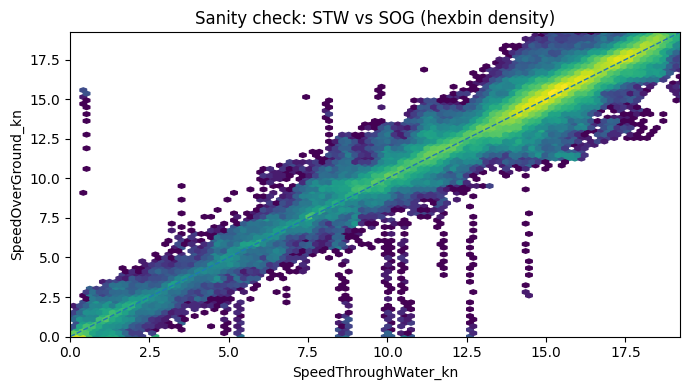

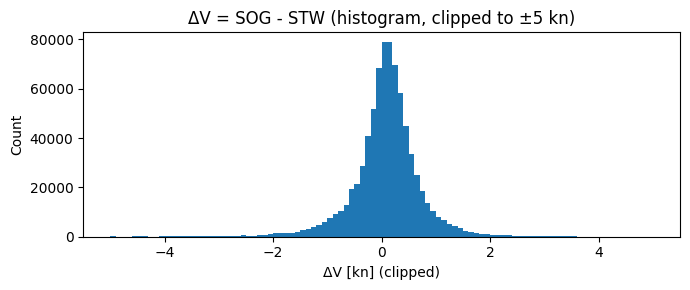

ΔV quantiles [kn]:
0.01   -1.960065
0.05   -0.952833
0.50    0.105834
0.95    1.035834
0.99    1.853813
Name: dV_kn, dtype: float64
Share with |ΔV| > 1 kn: 0.09979196113187509


In [128]:
# 5.4 Sanity relationship: STW vs SOG, and ΔV = SOG - STW

cols = ["SpeedThroughWater_kn", "SpeedOverGround_kn"]
tmp = df[cols].dropna().copy()
tmp["dV_kn"] = tmp["SpeedOverGround_kn"] - tmp["SpeedThroughWater_kn"]

# STW vs SOG (density via hexbin)
m = np.nanpercentile(pd.concat([tmp["SpeedThroughWater_kn"], tmp["SpeedOverGround_kn"]]), 99)

plt.figure(figsize=(7, 4))
plt.title("Sanity check: STW vs SOG (hexbin density)")
plt.hexbin(tmp["SpeedThroughWater_kn"], tmp["SpeedOverGround_kn"], gridsize=100, bins="log", mincnt=1)
plt.plot([0, m], [0, m], linestyle="--", linewidth=1)  # 1:1 line
plt.xlim(0, m); plt.ylim(0, m)
plt.xlabel("SpeedThroughWater_kn"); plt.ylabel("SpeedOverGround_kn")
plt.tight_layout()
plt.show()

# ΔV distribution (clipped for readability)
clip = 5  # knots
plt.figure(figsize=(7, 3))
plt.title(f"ΔV = SOG - STW (histogram, clipped to ±{clip} kn)")
plt.hist(tmp["dV_kn"].clip(-clip, clip), bins=100)
plt.xlabel("ΔV [kn] (clipped)"); plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("ΔV quantiles [kn]:")
print(tmp["dV_kn"].quantile([0.01, 0.05, 0.50, 0.95, 0.99]))
print("Share with |ΔV| > 1 kn:", (tmp["dV_kn"].abs() > 1).mean())


In [129]:
import pandas as pd
import numpy as np

N = len(df)

# Reuse existing signals
stw = df["SpeedThroughWater_kn"]
sog = df["SpeedOverGround_kn"]
pwr = df["ShaftPower_kW"]
rpm = df["ShaftRev_rpm"]

dV = sog - stw

summary = pd.DataFrame({
    "metric": [
        "Total rows",
        "Time span [days]",
        "Mean rows/day",
        "Days below 80% 1-min coverage",
        "Gaps > 6h (count)",
        "Telemetry mean missing fraction",
        "Metocean mean missing fraction",
        "Share zero-prop (power<=50 or rpm<=1)",
        "Share low-speed (STW<=2 kn)",
        "Share either (union)",
        "Share |ΔV| > 1 kn",
        "ΔV median [kn]",
        "ΔV 95% interval [kn]"
    ],
    "value": [
        N,
        (df.index.max() - df.index.min()).days,
        df.resample("D").size().mean(),
        int((df.resample("D").size() < 0.8*1440).sum()),
        int((df.index.to_series().diff() > pd.Timedelta(hours=6)).sum()),
        df[[c for c in df.columns if c not in ["mwd","mwp","swh","u10","v10","uo","vo","thetao","so","rho_surface"]]].isna().mean().mean(),
        df[[c for c in ["mwd","mwp","swh","u10","v10","uo","vo","thetao","so","rho_surface"] if c in df.columns]].isna().mean().mean(),
        ((pwr <= 50.0) | (rpm <= 1.0)).mean(),
        (stw <= 2.0).mean(),
        (((pwr <= 50.0) | (rpm <= 1.0)) | (stw <= 2.0)).mean(),
        (dV.abs() > 1.0).mean(),
        dV.median(),
        f"[{dV.quantile(0.05):.3f}, {dV.quantile(0.95):.3f}]"
    ]
})

summary


,metric,value
0,Total rows,780345
1,Time span [days],935
2,Mean rows/day,833.701923
3,Days below 80% 1-min coverage,458
4,Gaps > 6h (count),129
5,Telemetry mean missing fraction,0.005695
6,Metocean mean missing fraction,0.0199
7,Share zero-prop (power<=50 or rpm<=1),0.051599
8,Share low-speed (STW<=2 kn),0.048412
9,Share either (union),0.054122


<Axes: >

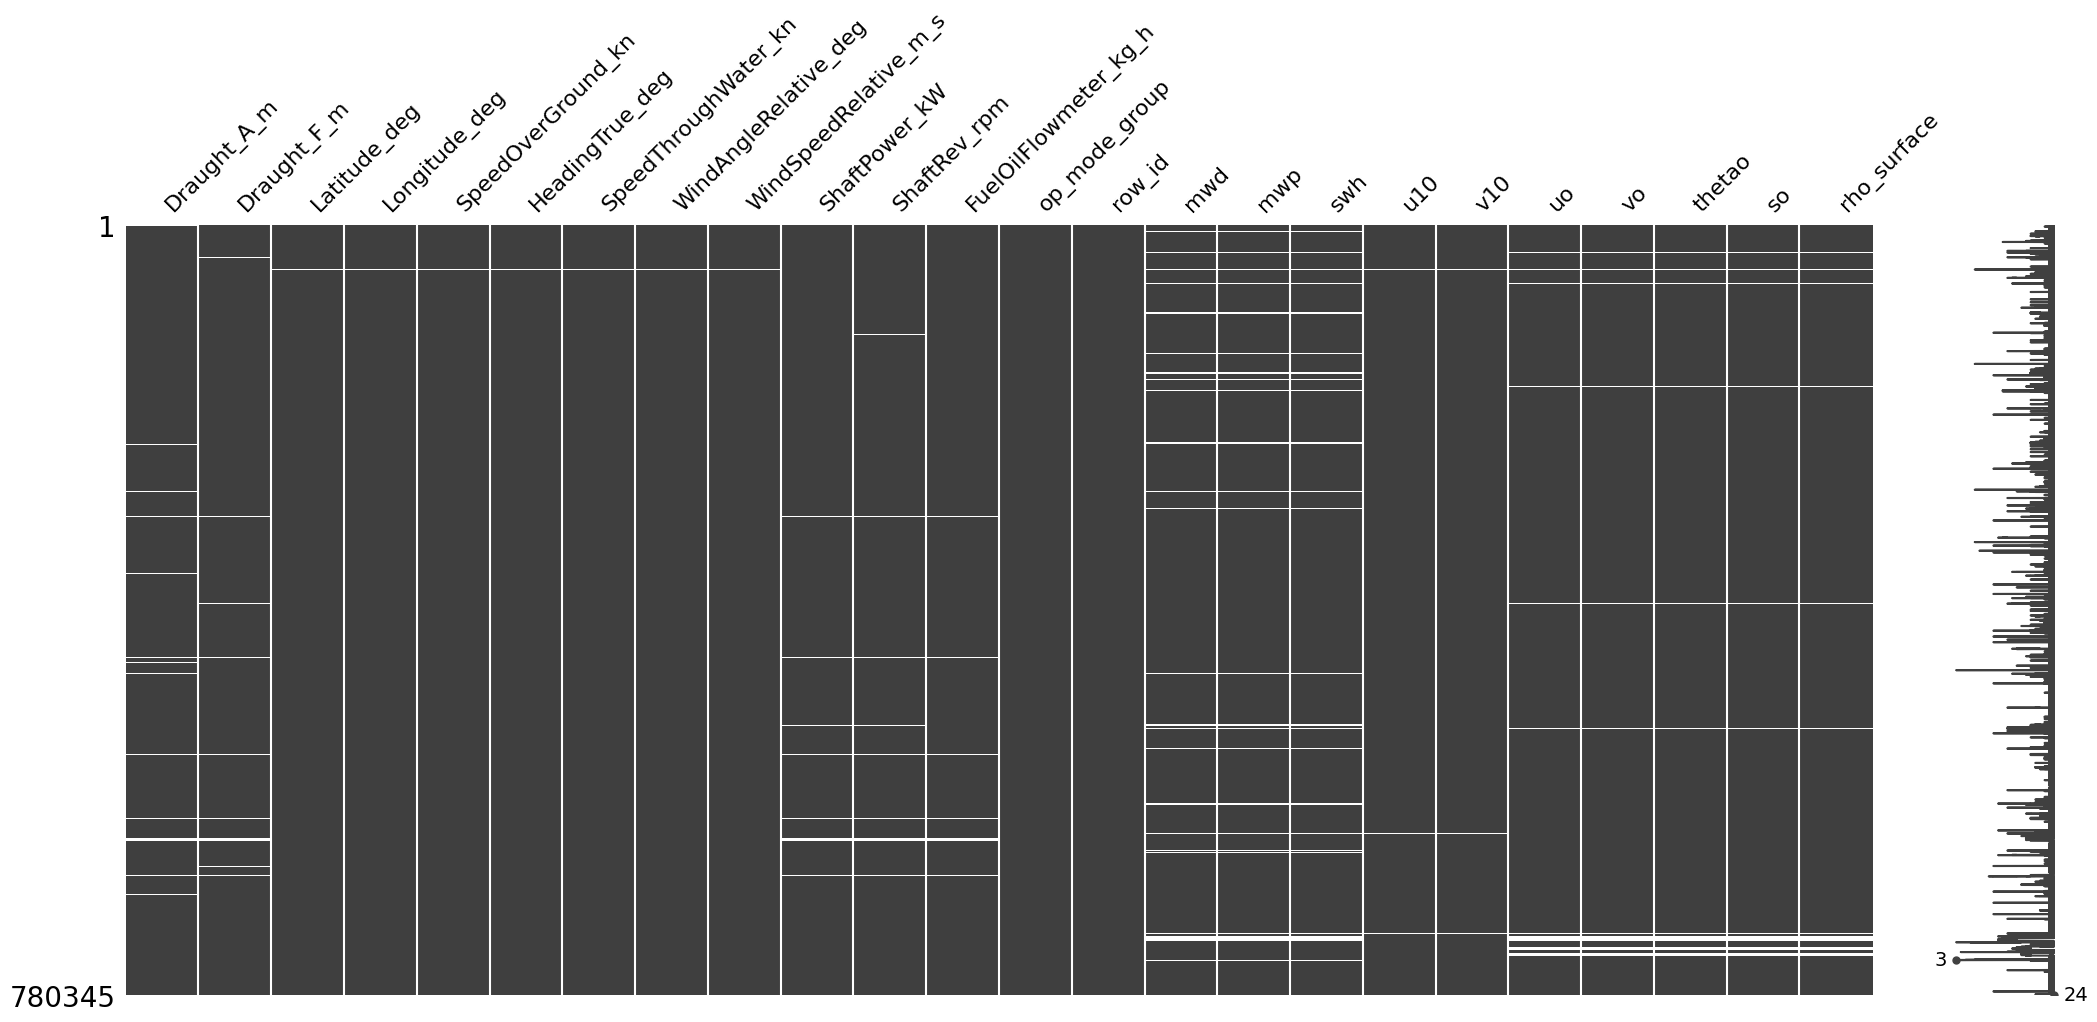

In [130]:
# Missing Data Visualization
msno.matrix(df)

In [131]:
import pandas as pd

# --- Define critical variables (Table 1) ---
critical_vars = [
    "SpeedThroughWater_kn",
    "ShaftPower_kW",
    "ShaftRev_rpm",
    "HeadingTrue_deg",
    "Draught_F_m",
    "Draught_A_m",
    # Legg til metocean her hvis de er kritiske i din pipeline:
     "u10", "v10", "swh", "mwd", "mwp"
]

# Keep only those that actually exist (robust if names differ slightly)
critical_vars = [c for c in critical_vars if c in df.columns]

# --- Joint completeness ---
n_total = len(df)
complete_mask = df[critical_vars].notna().all(axis=1)
n_complete = int(complete_mask.sum())

print("Critical variables used:", critical_vars)
print(f"Rows total: {n_total:,}")
print(f"Rows with ALL critical vars present: {n_complete:,} ({n_complete/n_total:.3%})")
print(f"Rows dropped by 'no critical NaNs': {n_total-n_complete:,} ({(n_total-n_complete)/n_total:.3%})")

# --- Contribution: which critical vars cause the most drops? ---
missing_counts = df[critical_vars].isna().sum().sort_values(ascending=False)
missing_frac = (missing_counts / n_total).rename("missing_fraction")

summary = pd.concat(
    [missing_counts.rename("missing_rows"), missing_frac],
    axis=1
)

display(summary)

# Optional: how many rows are missing at least one critical variable?
print(f"Rows with ANY critical missing: {(~complete_mask).sum():,} ({(~complete_mask).mean():.3%})")


Critical variables used: ['SpeedThroughWater_kn', 'ShaftPower_kW', 'ShaftRev_rpm', 'HeadingTrue_deg', 'Draught_F_m', 'Draught_A_m', 'u10', 'v10', 'swh', 'mwd', 'mwp']
Rows total: 780,345
Rows with ALL critical vars present: 734,269 (94.095%)
Rows dropped by 'no critical NaNs': 46,076 (5.905%)


,missing_rows,missing_fraction
swh,25099,0.032164
mwd,25099,0.032164
mwp,25099,0.032164
Draught_A_m,17737,0.022730
Draught_F_m,12068,0.015465
ShaftRev_rpm,10295,0.013193
ShaftPower_kW,9842,0.012612
u10,2034,0.002607
v10,2034,0.002607
SpeedThroughWater_kn,530,0.000679


Rows with ANY critical missing: 46,076 (5.905%)


In [132]:
import pandas as pd

telemetry_crit = ["SpeedThroughWater_kn", "ShaftPower_kW", "ShaftRev_rpm", "HeadingTrue_deg", "Draught_F_m", "Draught_A_m"]
metocean_crit  = ["u10", "v10", "swh", "mwd", "mwp"]

telemetry_crit = [c for c in telemetry_crit if c in df.columns]
metocean_crit  = [c for c in metocean_crit  if c in df.columns]

miss_tel = df[telemetry_crit].isna().any(axis=1)
miss_met = df[metocean_crit].isna().any(axis=1)

overlap = pd.DataFrame({
    "missing_telemetry_any": [miss_tel.sum(), miss_tel.mean()],
    "missing_metocean_any":  [miss_met.sum(), miss_met.mean()],
    "missing_both":          [(miss_tel & miss_met).sum(), (miss_tel & miss_met).mean()],
    "missing_tel_only":      [(miss_tel & ~miss_met).sum(), (miss_tel & ~miss_met).mean()],
    "missing_met_only":      [(~miss_tel & miss_met).sum(), (~miss_tel & miss_met).mean()],
}, index=["count", "fraction"])

display(overlap)

# Andel av "dropped by no critical NaNs" som skyldes metocean vs telemetry
critical_vars = telemetry_crit + metocean_crit
complete_all = df[critical_vars].notna().all(axis=1)
dropped = ~complete_all

print(f"Rows dropped (any critical missing): {dropped.sum():,} ({dropped.mean():.3%})")
print(f"  ...where metocean missing (any):    {(dropped & miss_met).sum():,} ({((dropped & miss_met).sum()/dropped.sum()):.3%} of dropped)")
print(f"  ...where telemetry missing (any):   {(dropped & miss_tel).sum():,} ({((dropped & miss_tel).sum()/dropped.sum()):.3%} of dropped)")
print(f"  ...metocean-only among dropped:     {(dropped & ~miss_tel & miss_met).sum():,}")
print(f"  ...telemetry-only among dropped:    {(dropped & miss_tel & ~miss_met).sum():,}")


,missing_telemetry_any,missing_metocean_any,missing_both,missing_tel_only,missing_met_only
count,22130.000000,25099.000000,1153.000000,20977.000000,23946.000000
fraction,0.028359,0.032164,0.001478,0.026882,0.030686


Rows dropped (any critical missing): 46,076 (5.905%)
  ...where metocean missing (any):    25,099 (54.473% of dropped)
  ...where telemetry missing (any):   22,130 (48.029% of dropped)
  ...metocean-only among dropped:     23,946
  ...telemetry-only among dropped:    20,977


,telemetry_missing_runs,metocean_missing_runs
len_min,,
1–5 min,12327,104
6–60 min,46,42
1–6 h,5,89
6–24 h,4,11
>24 h,3,1


Telemetry missing-runs: 12385 | median len [min]: 1.0 | p95: 1.0
Metocean  missing-runs: 247 | median len [min]: 22.0 | p95: 315.49999999999994


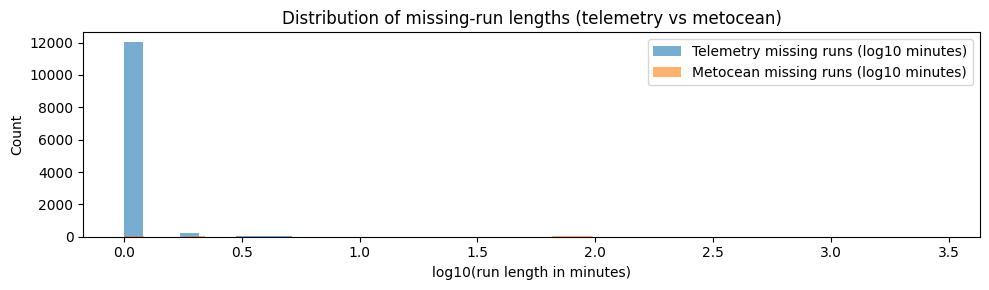

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Anta df har timestamp som index (du har allerede satt index)
telemetry_crit = ["SpeedThroughWater_kn", "ShaftPower_kW", "ShaftRev_rpm", "HeadingTrue_deg", "Draught_F_m", "Draught_A_m"]
metocean_crit  = ["u10", "v10", "swh", "mwd", "mwp"]

telemetry_crit = [c for c in telemetry_crit if c in df.columns]
metocean_crit  = [c for c in metocean_crit  if c in df.columns]

miss_tel = df[telemetry_crit].isna().any(axis=1)
miss_met = df[metocean_crit].isna().any(axis=1)

def run_lengths_minutes(miss_bool: pd.Series) -> pd.Series:
    miss_bool = miss_bool.astype(bool)
    # Finn start/slutt på runs
    change = miss_bool.ne(miss_bool.shift(fill_value=False))
    run_id = change.cumsum()
    runs = miss_bool.groupby(run_id).agg(["first", "size"])
    # Behold kun runs der first==True (dvs missing-runs)
    miss_runs = runs[runs["first"]].copy()
    # Størrelse i minutter (1 rad ~ 1 min; hvis ikke, er dette fortsatt “antall rader”)
    miss_runs["len_min"] = miss_runs["size"]
    return miss_runs["len_min"]

tel_runs = run_lengths_minutes(miss_tel)
met_runs = run_lengths_minutes(miss_met)

def bucket_counts(run_lengths):
    bins = [1, 5, 60, 360, 1440, 10**9]  # 1–5min, 6–60, 1–6h, 6–24h, >24h
    labels = ["1–5 min", "6–60 min", "1–6 h", "6–24 h", ">24 h"]
    cats = pd.cut(run_lengths, bins=bins, labels=labels, right=True, include_lowest=True)
    return cats.value_counts().sort_index()

summary = pd.DataFrame({
    "telemetry_missing_runs": bucket_counts(tel_runs),
    "metocean_missing_runs":  bucket_counts(met_runs),
}).fillna(0).astype(int)

display(summary)

print("Telemetry missing-runs:", len(tel_runs), "| median len [min]:", tel_runs.median(), "| p95:", tel_runs.quantile(0.95))
print("Metocean  missing-runs:", len(met_runs), "| median len [min]:", met_runs.median(), "| p95:", met_runs.quantile(0.95))

# Enkel visualisering (log-x gjør at lange runs synes)
plt.figure(figsize=(10,3))
plt.hist(np.log10(tel_runs.clip(lower=1)), bins=40, alpha=0.6, label="Telemetry missing runs (log10 minutes)")
plt.hist(np.log10(met_runs.clip(lower=1)), bins=40, alpha=0.6, label="Metocean missing runs (log10 minutes)")
plt.xlabel("log10(run length in minutes)"); plt.ylabel("Count")
plt.title("Distribution of missing-run lengths (telemetry vs metocean)")
plt.legend()
plt.tight_layout(); plt.show()


,missing_any,missing_tel,missing_met
timestamp,,,
2025-03-20 00:00:00+00:00,1.000000,1.000000,0.000000
2024-08-09 00:00:00+00:00,1.000000,0.030137,1.000000
2023-06-05 00:00:00+00:00,1.000000,0.000000,1.000000
2024-08-03 00:00:00+00:00,1.000000,0.045872,1.000000
2025-04-14 00:00:00+00:00,1.000000,0.979130,0.393043
2023-06-23 00:00:00+00:00,1.000000,0.044444,1.000000
2025-03-19 00:00:00+00:00,1.000000,1.000000,0.000000
2025-03-18 00:00:00+00:00,1.000000,1.000000,0.000000
2025-06-15 00:00:00+00:00,1.000000,0.006259,1.000000


Share of all dropped rows occurring in worst 5 days: 0.023
Share of all dropped rows occurring in worst 10 days: 0.068
Share of all dropped rows occurring in worst 20 days: 0.269
Share of all dropped rows occurring in worst 50 days: 0.533


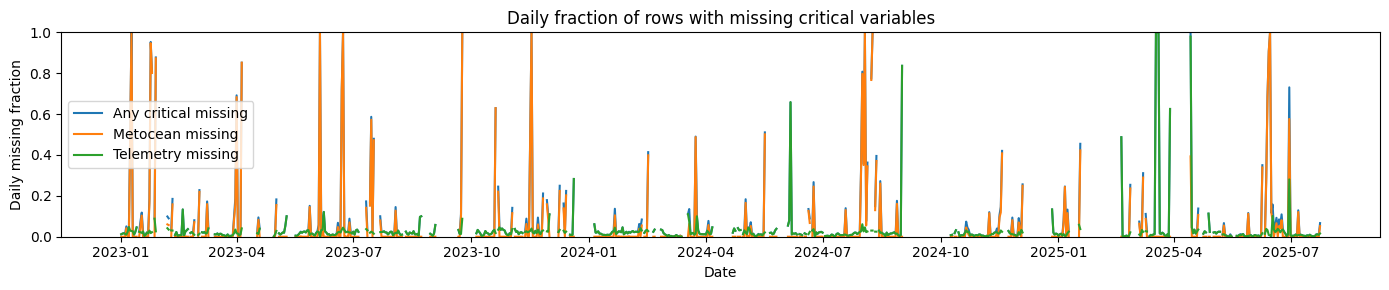

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

telemetry_crit = ["SpeedThroughWater_kn", "ShaftPower_kW", "ShaftRev_rpm", "HeadingTrue_deg", "Draught_F_m", "Draught_A_m"]
metocean_crit  = ["u10", "v10", "swh", "mwd", "mwp"]

telemetry_crit = [c for c in telemetry_crit if c in df.columns]
metocean_crit  = [c for c in metocean_crit  if c in df.columns]

miss_tel = df[telemetry_crit].isna().any(axis=1)
miss_met = df[metocean_crit].isna().any(axis=1)
miss_any = miss_tel | miss_met

daily = pd.DataFrame({
    "missing_any": miss_any,
    "missing_tel": miss_tel,
    "missing_met": miss_met,
}).resample("D").mean()

# Top dager etter missing-fraction
top = daily.sort_values("missing_any", ascending=False).head(15)
display(top)

# Hvor mye av total bortfall kommer fra de verste dagene?
total_missing_rows = miss_any.sum()
for k in [5, 10, 20, 50]:
    worst_days = daily.sort_values("missing_any", ascending=False).head(k).index
    rows_in_worst_days = miss_any[miss_any].loc[worst_days.min():worst_days.max()]  # enkel guard, men vi trenger faktisk presist per dag:
    # presist:
    miss_by_day = miss_any.resample("D").sum()
    share = miss_by_day.loc[worst_days].sum() / total_missing_rows
    print(f"Share of all dropped rows occurring in worst {k} days: {share:.3f}")

# Plot missingness per day (any vs met vs tel)
plt.figure(figsize=(14,3))
plt.plot(daily.index, daily["missing_any"], label="Any critical missing")
plt.plot(daily.index, daily["missing_met"], label="Metocean missing")
plt.plot(daily.index, daily["missing_tel"], label="Telemetry missing")
plt.ylim(0, 1)
plt.ylabel("Daily missing fraction"); plt.xlabel("Date")
plt.title("Daily fraction of rows with missing critical variables")
plt.legend()
plt.tight_layout(); plt.show()


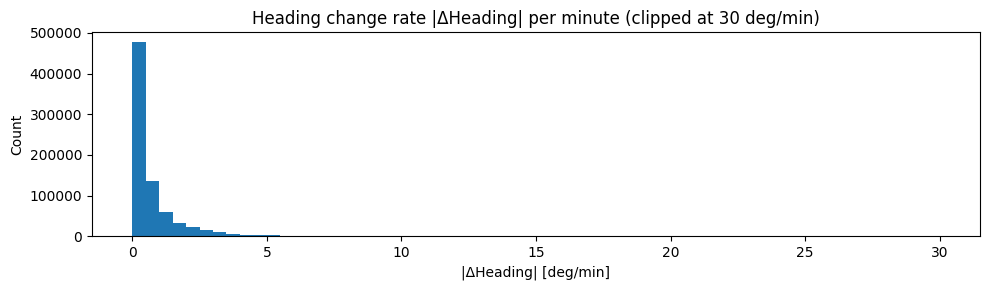

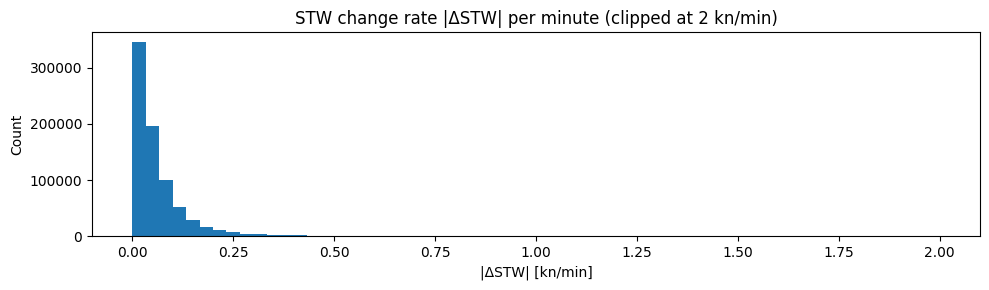

Share with |ΔHeading| > 2 deg/min: 0.09521173327182209
Share with |ΔSTW| > 0.2 kn/min: 0.05170149100718272


In [135]:
import numpy as np
import matplotlib.pyplot as plt

# Turn-rate (deg/min) og STW endring (kn/min) som proxy for manøvrering / transients
d_heading = df["HeadingTrue_deg"].diff()
# wrap til [-180, 180] for å unngå hopp ved -180/180
d_heading = (d_heading + 180) % 360 - 180

turn_rate_deg_min = d_heading.abs()  # siden 1-min sampling ~ deg per min
dstw_kn_min = df["SpeedThroughWater_kn"].diff().abs()

plt.figure(figsize=(10,3))
plt.hist(turn_rate_deg_min.dropna().clip(upper=30), bins=60)
plt.title("Heading change rate |ΔHeading| per minute (clipped at 30 deg/min)")
plt.xlabel("|ΔHeading| [deg/min]"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,3))
plt.hist(dstw_kn_min.dropna().clip(upper=2), bins=60)
plt.title("STW change rate |ΔSTW| per minute (clipped at 2 kn/min)")
plt.xlabel("|ΔSTW| [kn/min]"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

print("Share with |ΔHeading| > 2 deg/min:", (turn_rate_deg_min > 2).mean())
print("Share with |ΔSTW| > 0.2 kn/min:", (dstw_kn_min > 0.2).mean())


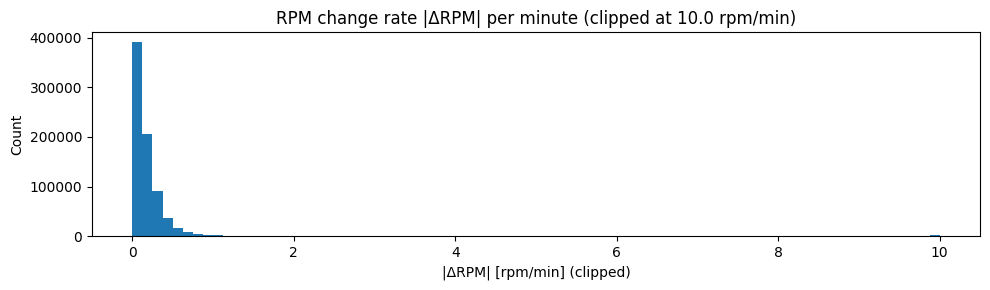

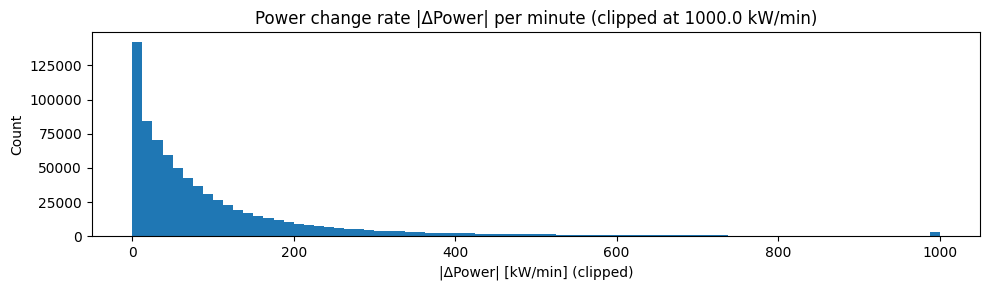

ΔRPM quantiles [rpm/min]:
0.50    0.120000
0.95    0.528571
0.99    1.900000

ΔPower quantiles [kW/min]:
0.50     56.833333
0.95    404.833333
0.99    772.916667

Share with |ΔRPM| > 2.0 rpm/min: 0.00940097008374501
Share with |ΔPower| > 200.0 kW/min: 0.14897128834041354


In [136]:
import numpy as np
import matplotlib.pyplot as plt

# Forutsetter at df har timestamp som index (UTC) og er sortert
df_ = df.sort_index()

# 1-min differanser (absolutt endring per minutt)
d_rpm = df_["ShaftRev_rpm"].diff().abs()
d_pwr = df_["ShaftPower_kW"].diff().abs()

# Klipp for lesbarhet (juster ved behov)
rpm_clip = 10.0     # rpm/min
pwr_clip = 1000.0   # kW/min

plt.figure(figsize=(10,3))
plt.title(f"RPM change rate |ΔRPM| per minute (clipped at {rpm_clip} rpm/min)")
plt.hist(d_rpm.dropna().clip(upper=rpm_clip), bins=80)
plt.xlabel("|ΔRPM| [rpm/min] (clipped)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.title(f"Power change rate |ΔPower| per minute (clipped at {pwr_clip} kW/min)")
plt.hist(d_pwr.dropna().clip(upper=pwr_clip), bins=80)
plt.xlabel("|ΔPower| [kW/min] (clipped)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Enkle nøkkeltall du kan sitere i EDA-teksten
print("ΔRPM quantiles [rpm/min]:")
print(d_rpm.dropna().quantile([0.50, 0.95, 0.99]).to_string())

print("\nΔPower quantiles [kW/min]:")
print(d_pwr.dropna().quantile([0.50, 0.95, 0.99]).to_string())

# Eksempelterskler (sett disse lik det du faktisk bruker i Methods)
rpm_thr = 2.0
pwr_thr = 200.0
print(f"\nShare with |ΔRPM| > {rpm_thr} rpm/min:", float((d_rpm > rpm_thr).mean()))
print(f"Share with |ΔPower| > {pwr_thr} kW/min:", float((d_pwr > pwr_thr).mean()))


In [137]:
import numpy as np
import pandas as pd

# --- Helpers ---
def heading_rate_deg_per_min(heading_deg: pd.Series) -> pd.Series:
    """Compute absolute heading change rate [deg/min] handling wrap-around."""
    h = pd.to_numeric(heading_deg, errors="coerce")
    h_rad = np.deg2rad(h.values.astype(float))
    h_unwrap = np.unwrap(h_rad)
    dh_deg = np.abs(np.rad2deg(np.diff(h_unwrap)))
    # dt in minutes
    dt_min = pd.Series(h.index).diff().dt.total_seconds().to_numpy()[1:] / 60.0
    rate = dh_deg / dt_min
    return pd.Series(rate, index=h.index[1:])

def abs_rate_per_min(series: pd.Series) -> pd.Series:
    """Absolute change rate per minute for a numeric series."""
    x = pd.to_numeric(series, errors="coerce")
    dx = np.abs(x.diff())
    dt_min = x.index.to_series().diff().dt.total_seconds() / 60.0
    return (dx / dt_min).replace([np.inf, -np.inf], np.nan)

# --- Compute rates (robustly) ---
d_heading = heading_rate_deg_per_min(df["HeadingTrue_deg"])
d_stw     = abs_rate_per_min(df["SpeedThroughWater_kn"])
d_rpm     = abs_rate_per_min(df["ShaftRev_rpm"])
d_power   = abs_rate_per_min(df["ShaftPower_kW"])

# --- Candidate thresholds (use the ones you already reported in text/EDA) ---
thr = {
    "|ΔHeading| [deg/min]": 2.0,
    "|ΔSTW| [kn/min]": 0.2,
    "|ΔRPM| [rpm/min]": 2.0,
    "|ΔPower| [kW/min]": 200.0,
}

flags = pd.DataFrame({
    "|ΔHeading| [deg/min]": d_heading > thr["|ΔHeading| [deg/min]"],
    "|ΔSTW| [kn/min]":      d_stw     > thr["|ΔSTW| [kn/min]"],
    "|ΔRPM| [rpm/min]":     d_rpm     > thr["|ΔRPM| [rpm/min]"],
    "|ΔPower| [kW/min]":    d_power   > thr["|ΔPower| [kW/min]"],
}).dropna(how="all")  # keep rows where at least one metric exists

# Align indices (rates start at t1)
base_n = len(flags)

summary = []
for k in thr:
    s = flags[k].mean()  # share flagged
    q50 = pd.Series({"|ΔHeading| [deg/min]": d_heading,
                     "|ΔSTW| [kn/min]": d_stw,
                     "|ΔRPM| [rpm/min]": d_rpm,
                     "|ΔPower| [kW/min]": d_power}[k]).quantile(0.50)
    q95 = pd.Series({"|ΔHeading| [deg/min]": d_heading,
                     "|ΔSTW| [kn/min]": d_stw,
                     "|ΔRPM| [rpm/min]": d_rpm,
                     "|ΔPower| [kW/min]": d_power}[k]).quantile(0.95)
    q99 = pd.Series({"|ΔHeading| [deg/min]": d_heading,
                     "|ΔSTW| [kn/min]": d_stw,
                     "|ΔRPM| [rpm/min]": d_rpm,
                     "|ΔPower| [kW/min]": d_power}[k]).quantile(0.99)
    summary.append([k, thr[k], s, q50, q95, q99])

summary_df = pd.DataFrame(
    summary,
    columns=["metric", "candidate_threshold", "share_flagged", "q50", "q95", "q99"]
).set_index("metric")

summary_df.loc["Union (any transient flag)"] = {
    "candidate_threshold": np.nan,
    "share_flagged": flags.any(axis=1).mean(),
    "q50": np.nan, "q95": np.nan, "q99": np.nan
}

print(f"Rate rows evaluated (t1..end): {base_n:,}")
display(summary_df)


Rate rows evaluated (t1..end): 780,345


,candidate_threshold,share_flagged,q50,q95,q99
metric,,,,,
|ΔHeading| [deg/min],2.0,0.004096,0.349999,2.383327,5.816902
|ΔSTW| [kn/min],0.2,0.051516,0.038334,0.203333,0.435000
|ΔRPM| [rpm/min],2.0,0.009190,0.120000,0.527273,1.850000
|ΔPower| [kW/min],200.0,0.148719,56.750000,403.416667,766.500000
Union (any transient flag),NaN,0.188501,NaN,NaN,NaN
